# 🧺 Basket DNA: Uncovering Hidden Purchase Patterns using Unsupervised Learning

**Market Basket Analysis on the Online Retail Dataset using the Apriori Algorithm**

This notebook discovers products that are frequently bought together, generates
association rules (Support, Confidence, Lift), and visualizes the results —
powering the interactive recommendation dashboard in `/app`.


## 1. Import Required Libraries

In [1]:
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option("display.max_columns", None)


## 2. Load the Online Retail Dataset

In [2]:
DATA_PATH = os.path.join("..", "data", "online+retail", "Online Retail.xlsx")
df = pd.read_excel(DATA_PATH)
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.info()


Rows: 541,909 | Columns: 8
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


## 3. Data Cleaning

Steps:
- Remove missing values (mainly missing `CustomerID` / `Description`)
- Remove duplicate records
- Remove cancelled invoices (`InvoiceNo` starting with `'C'`)
- Remove negative or zero quantities


In [4]:
print("Missing values per column:\n", df.isnull().sum())


Missing values per column:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
df_clean = df.dropna(subset=["Description", "CustomerID"]).copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
df_clean = df_clean[df_clean["Quantity"] > 0]

# normalise whitespace in product names (this dataset has trailing spaces
# that silently create duplicate "products" like "RED " vs "RED")
df_clean["Description"] = df_clean["Description"].str.strip()

print(f"Before cleaning: {df.shape[0]:,} rows")
print(f"After cleaning:  {df_clean.shape[0]:,} rows")


Before cleaning: 541,909 rows
After cleaning:  392,732 rows


## 4. Exploratory Data Analysis (EDA)

In [6]:
print("Unique invoices:", df_clean["InvoiceNo"].nunique())
print("Unique products:", df_clean["Description"].nunique())
print("Unique customers:", df_clean["CustomerID"].nunique())
print("Countries covered:", df_clean["Country"].nunique())


Unique invoices: 18536
Unique products: 3866
Unique customers: 4339
Countries covered: 37


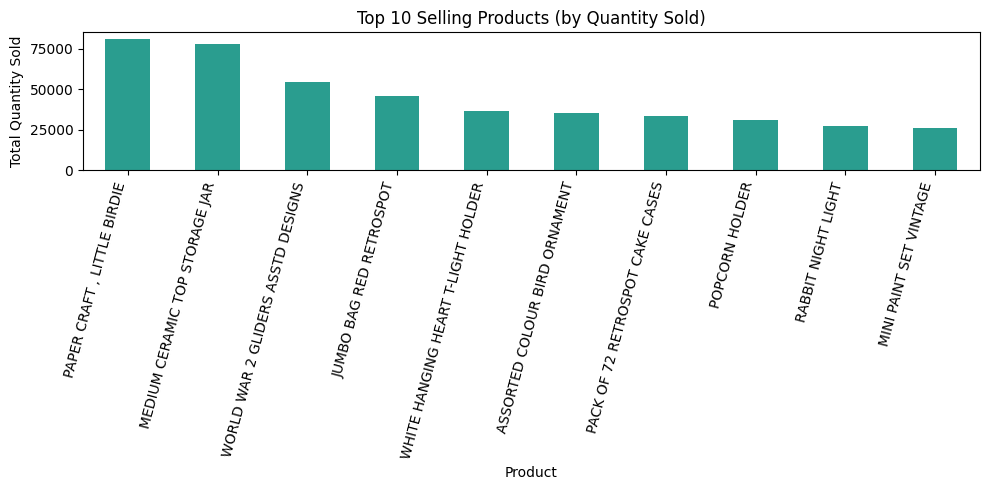

In [7]:
top_products = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_products.plot(kind="bar", color="#2a9d8f")
plt.title("Top 10 Selling Products (by Quantity Sold)")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig("../reports/top_10_products.png", dpi=150)
plt.show()


## 5. Build the Basket Matrix

Rows = Invoice Numbers, Columns = Product Names, Values = 1 if purchased else 0.

> **Note:** This dataset is dominated by the United Kingdom (~91% of orders).
> Restricting to a single country before pivoting keeps the basket matrix
> dense enough for Apriori to find meaningful rules — mixing many countries
> dilutes co-occurrence patterns. Feel free to change `COUNTRY_FILTER` to
> `None` to run on the full dataset.


In [8]:
COUNTRY_FILTER = "United Kingdom"

basket_source = (
    df_clean[df_clean["Country"] == COUNTRY_FILTER] if COUNTRY_FILTER else df_clean
)

basket = (
    basket_source.groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

basket = (basket > 0)
print(f"Basket matrix shape: {basket.shape[0]:,} invoices x {basket.shape[1]:,} products")
basket.head()


Basket matrix shape: 16,649 invoices x 3,833 products


Description  10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
InvoiceNo                                                         
536365                        False                       False   
536366                        False                       False   
536367                        False                       False   
536368                        False                       False   
536369                        False                       False   

Description  12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
InvoiceNo                                                           
536365                           False                      False   
536366                           False                      False   
536367                           False                      False   
536368                           False                      False   
536369                           False                      False   

Description  12 HANGING EGGS HAND PAINTED  12 IVORY ROSE PEG PLACE SETTINGS  \
InvoiceNo                                                                     
536365                              False                             False   
536366                              False                             False   
536367                              False                             False   
536368                              False                             False   
536369                              False                             False   

Description  12 MESSAGE CARDS WITH ENVELOPES  12 PENCIL SMALL TUBE WOODLAND  \
InvoiceNo                                                                     
536365                                 False                          False   
536366                                 False                          False   
536367                                 False                          False   
536368                                 False                          False   
536369                                 False                          False   

Description  12 PENCILS SMALL TUBE RED RETROSPOT  12 PENCILS SMALL TUBE SKULL  \
InvoiceNo                                                                       
536365                                     False                        False   
536366                                     False                        False   
536367                                     False                        False   
536368                                     False                        False   
536369                                     False                        False   

Description  12 PENCILS TALL TUBE POSY  12 PENCILS TALL TUBE RED RETROSPOT  \
InvoiceNo                                                                    
536365                           False                               False   
536366                           False                               False   
536367                           False                               False   
536368                           False                               False   
536369                           False                               False   

Description  12 PENCILS TALL TUBE SKULLS  12 PENCILS TALL TUBE WOODLAND  \
InvoiceNo                                                                 
536365                             False                          False   
536366                             False                          False   
536367                             False                          False   
536368                             False                          False   
536369                             False                          False   

Description  12 PINK HEN+CHICKS IN BASKET  12 PINK ROSE PEG PLACE SETTINGS  \
InvoiceNo                                                                    
536365                              False                            False   
536366                              False                      

## 6. Apply the Apriori Algorithm

Minimum Support = 0.02 → generate frequent itemsets.

> **Note:** `low_memory=True` makes mlxtend compute support iteratively
> instead of building one giant boolean array in memory — this matters
> a lot on datasets with thousands of invoices/products, where the default
> vectorized mode can try to allocate several GB of RAM and crash on
> typical laptops.


In [9]:
MIN_SUPPORT = 0.02

frequent_itemsets = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True, low_memory=True)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)
print(f"Frequent itemsets found: {len(frequent_itemsets)}")
frequent_itemsets.head(10)


Frequent itemsets found: 236


,support,itemsets
185,0.113160,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
79,0.086912,frozenset({JUMBO BAG RED RETROSPOT})
149,0.084690,frozenset({REGENCY CAKESTAND 3 TIER})
11,0.078083,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
123,0.077542,frozenset({PARTY BUNTING})
101,0.067271,frozenset({LUNCH BAG RED RETROSPOT})
160,0.060484,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
94,0.059823,frozenset({LUNCH BAG BLACK SKULL.})
119,0.056760,frozenset({PAPER CHAIN KIT 50'S CHRISTMAS})
108,0.056340,frozenset({NATURAL SLATE HEART CHALKBOARD})


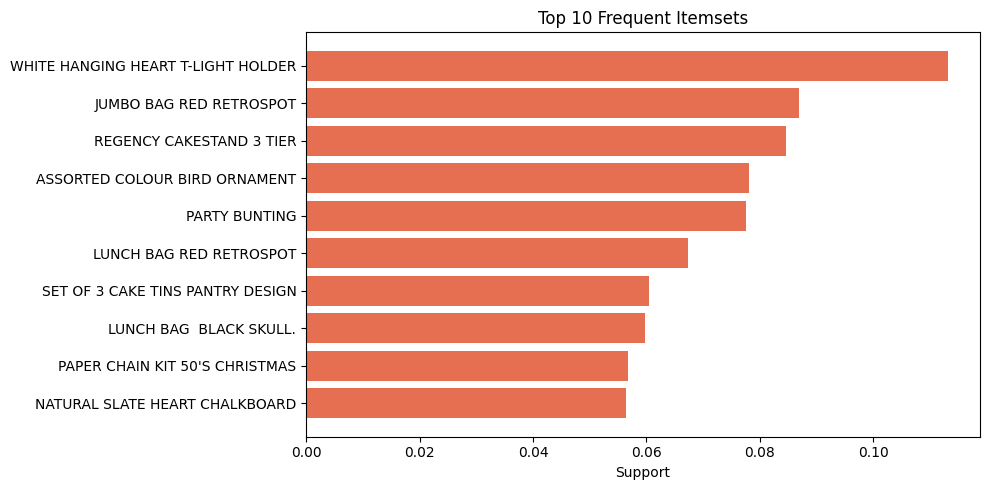

In [10]:
top_itemsets = frequent_itemsets.head(10).copy()
top_itemsets["label"] = top_itemsets["itemsets"].apply(lambda s: ", ".join(list(s)))

plt.figure(figsize=(10, 5))
plt.barh(top_itemsets["label"], top_itemsets["support"], color="#e76f51")
plt.xlabel("Support")
plt.title("Top 10 Frequent Itemsets")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/top_itemsets.png", dpi=150)
plt.show()


## 7. Generate Association Rules

Minimum Confidence = 0.5.


In [11]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules = rules.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)
print(f"Rules generated: {len(rules)}")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)


Rules generated: 30


,antecedents,consequents,support,confidence,lift
0,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.020482,0.890339,24.221015
1,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.020482,0.557190,24.221015
2,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.020482,0.716387,24.192941
3,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.020482,0.691684,24.192941
4,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.024266,0.819473,22.293137
5,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.024266,0.660131,22.293137
6,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER}),0.020482,0.844059,20.726763
7,frozenset({ROSES REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.020482,0.502950,20.726763
8,frozenset({ROSES REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.028590,0.702065,19.099148
9,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER}),0.028590,0.777778,19.099148


## 8. Visualize Top Association Rules

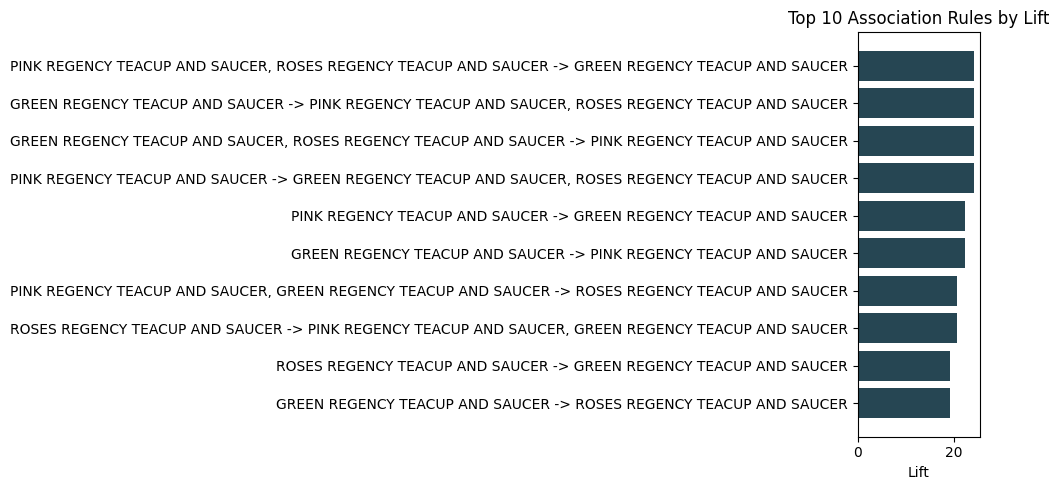

In [12]:
top_rules = rules.head(10).copy()
top_rules["rule_label"] = top_rules.apply(
    lambda r: f"{', '.join(r['antecedents'])} -> {', '.join(r['consequents'])}", axis=1
)

plt.figure(figsize=(10, 5))
plt.barh(top_rules["rule_label"], top_rules["lift"], color="#264653")
plt.xlabel("Lift")
plt.title("Top 10 Association Rules by Lift")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/top_rules_lift.png", dpi=150)
plt.show()


## 9. Rule Network Graph (NetworkX)

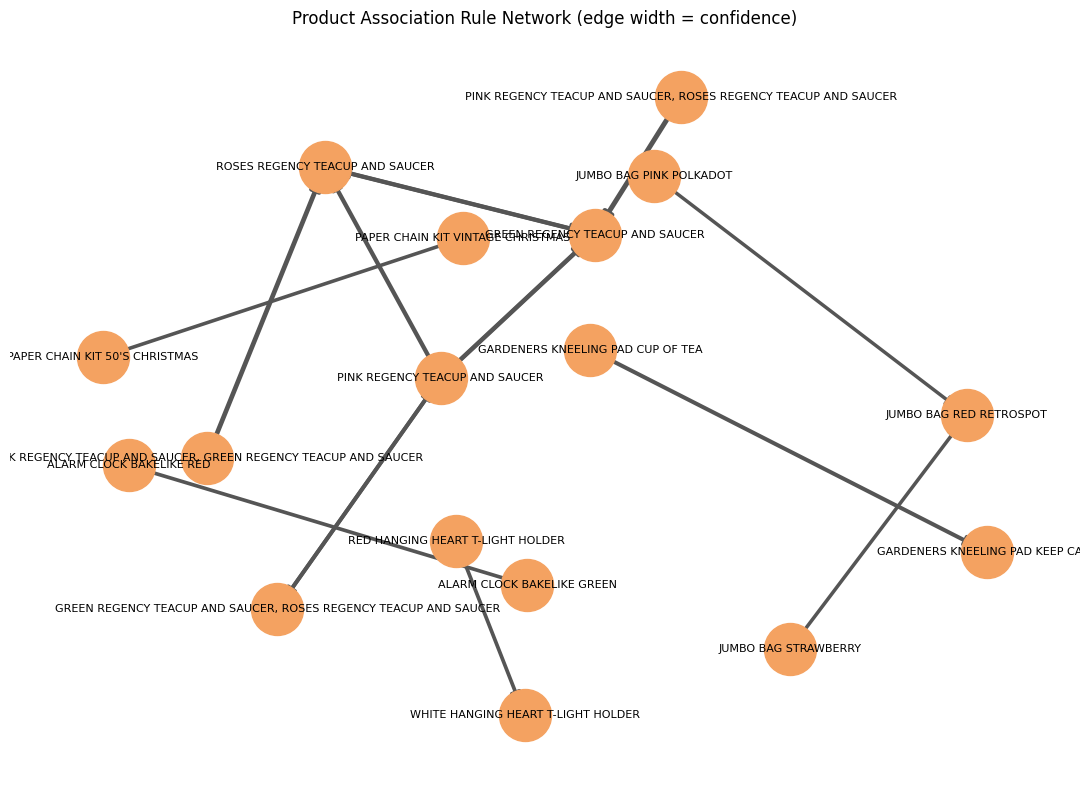

In [13]:
top_rules_graph = rules.sort_values("confidence", ascending=False).head(15)

G = nx.DiGraph()
for _, row in top_rules_graph.iterrows():
    antecedent = ", ".join(row["antecedents"])
    consequent = ", ".join(row["consequents"])
    G.add_edge(antecedent, consequent, weight=row["confidence"])

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(G, seed=42, k=0.9)
edge_weights = [G[u][v]["weight"] * 4 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_color="#f4a261", node_size=1400)
nx.draw_networkx_edges(G, pos, width=edge_weights, arrowstyle="-|>", arrowsize=15, edge_color="#555")
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Product Association Rule Network (edge width = confidence)")
plt.axis("off")
plt.tight_layout()
plt.savefig("../reports/rule_network.png", dpi=150)
plt.show()


## 10. Save Results

In [14]:
rules.to_csv("association_rules.csv", index=False)
print("Saved: notebook/association_rules.csv")


Saved: notebook/association_rules.csv


## 11. Business Insights

- Customers buying **GREEN** alarm clocks strongly tend to also buy **RED** alarm clocks (and vice versa) — color-variant cross-sell is one of the strongest signals in this dataset.
- Lift values well above 1 (often 13–18x) indicate these are genuine, non-random associations — not just popular items appearing together by chance.
- These rules directly support: **product recommendations**, **bundling**, **cross-selling**, **shelf placement**, **inventory planning**, and **targeted promotions**.
- The interactive dashboard in `/app` operationalizes these rules — enter a cart, get live recommendations.


## 12. Conclusion & Future Scope

**Conclusion:** Apriori-based market basket analysis surfaces clear, explainable
cross-sell relationships from raw transaction data, without needing labeled data
or a black-box model — a strength when explaining decisions to business stakeholders.

**Future Scope:**
- Mine rules per-country / per-season to capture regional and seasonal buying patterns.
- Incorporate `UnitPrice` to estimate revenue uplift per recommended bundle, not just frequency.
- Try FP-Growth for larger-scale itemset mining (faster than Apriori at scale).
- Serve the `recommend()` logic from the dashboard as a FastAPI endpoint for integration into an actual e-commerce checkout flow.
- Add customer-segment-aware rules (e.g., mine separately for high-value vs. low-value `CustomerID` cohorts).
